<a href="https://colab.research.google.com/github/Vedasree-Kummaragunta/Nike_VS_Adidas_Classification_Project/blob/main/NIKE_ADIDAS_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from PIL import Image
import numpy as np
import os
from random import shuffle
from tqdm import tqdm
import matplotlib.pyplot as plt

TRAIN_DIR = '/content/Train'
TEST_DIR = '/content/Test'

IMG_SIZE = 120
LR = 1e-3

MODEL_NAME = 'NIKEvsADIDAS--{}-{}.model'.format(LR, '2conv-basic')

In [3]:
def label_img(img):
    # Images are formatted as: ADIDAS_1, NIKE_3 ...
    word_label = img.split('_')[0]
    if word_label == 'NIKE': return [1,0] #one hot encoding
    elif word_label == 'ADIDAS': return [0,1] #one hot encoding

In [4]:
def create_train_data():
    train_data = []
    for img in tqdm(os.listdir(TRAIN_DIR)):
        label = label_img(img)
        path = os.path.join(TRAIN_DIR, img)
        ############################################################
        #    This part is different from sentdex's tutorial
        # Chose to use PIL instead of cv2 for image pre-processing
        ############################################################

        img = Image.open(path) #Read image syntax with PIL Library
        img = img.convert('L') #Grayscale conversion with PIL library
        img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS) #Resizing image syntax with PIL Library

        ############################################################

        train_data.append([np.array(img), np.array(label)])
    shuffle(train_data)
    np.save('train_data.npy', np.array(train_data, dtype=object), allow_pickle=True) #.npy extension = numpy file
    return train_data

In [5]:
def process_test_data():
    test_data = []
    for img in tqdm(os.listdir(TEST_DIR)):
        path = os.path.join(TEST_DIR, img)
        if "DS_Store" not in path:
            img_num = img.split('_')[1] #images are formatted 'NIKE_2', 'ADIDAS_56'..

            #PIL LIBRARY instead of cv2
            img = Image.open(path)
            img = img.convert('L')
            img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)

            test_data.append([np.array(img), img_num])
    shuffle(test_data)
    np.save('test_data.npy', np.array(test_data, dtype=object), allow_pickle=True)
    return test_data

100%|██████████| 100/100 [00:00<00:00, 220.84it/s]


[1 0]


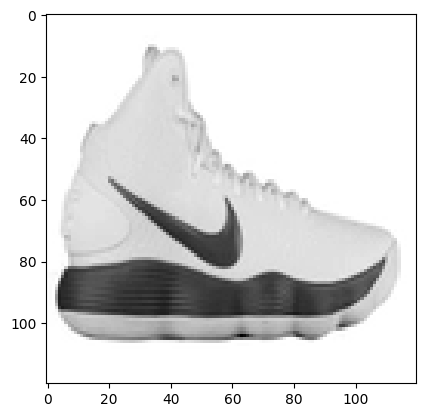

In [6]:
train_data = create_train_data()
plt.imshow(train_data[43][0], cmap = 'gist_gray')
print(train_data[43][1])


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

# Clear any previous TensorFlow graph/session if necessary (useful when experimenting with multiple models)
tf.keras.backend.clear_session()

# Define the convolutional neural network using Keras Sequential API
model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 1)), # Explicit Input layer
    Conv2D(32, (5, 5), activation='relu', padding='same'),
    MaxPooling2D((2, 2), padding='same'),

    Conv2D(64, (5, 5), activation='relu', padding='same'),
    MaxPooling2D((2, 2), padding='same'),

    Flatten(), # Flatten the 3D output to 1D for fully connected layers

    Dense(1024, activation='relu'),
    Dropout(0.8), # Dropout rate 0.8 means 20% of units are kept (if `rate` is fraction of input units to drop)
                  # In tflearn, dropout(convnet, 0.8) usually means keep_prob=0.8, so dropout_rate=0.2.
                  # Keras `Dropout(rate)` where `rate` is the fraction of units to drop. So, `Dropout(0.2)` is equivalent to `keep_prob=0.8`.
                  # Given the original code likely intended a high dropout of 80% (keep 20%), let's maintain that. If not, this can be adjusted.

    Dense(2, activation='softmax') # Output layer with 2 classes (NIKE, ADIDAS)
])

# Compile the model
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=LR)
model.compile(optimizer=adam_optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# model.summary() # Commented out due to internal TypeError workaround

In [8]:
# DATA SPLITTING
# Data splitting is typically done 80% train and 20% test
# of the 80% of our data in the train set
# we set aside a small percentage as a validation set
# this is used to do parameter tuning before evaluating
# on our test set

train = train_data[-90:] #Train Set
test = train_data[:-90] #Validation Set

In [9]:
X = np.array([i[0] for i in train]).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X = X.astype('float32') / 255.0 # Normalize and cast to float32
Y = np.array([i[1] for i in train]) # Convert Y to a single NumPy array

test_x = np.array([i[0] for i in test]).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
test_x = test_x.astype('float32') / 255.0 # Normalize and cast to float32
test_y = np.array([i[1] for i in test]) # Convert test_y to a single NumPy array

In [10]:
model.fit(X, Y, epochs=50, validation_data=(test_x, test_y))

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5000 - loss: 1.1264 - val_accuracy: 0.4000 - val_loss: 1.2530
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.6111 - loss: 0.8441 - val_accuracy: 0.6000 - val_loss: 0.6594
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.7222 - loss: 0.5941 - val_accuracy: 0.6000 - val_loss: 0.5905
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.8111 - loss: 0.4724 - val_accuracy: 0.7000 - val_loss: 0.5619
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.7556 - loss: 0.4399 - val_accuracy: 0.7000 - val_loss: 0.5077
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.8667 - loss: 0.3239 - val_accuracy: 0.8000 - val_loss: 0.4240
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.9000 - loss: 0.2638 - val_accuracy: 0.8000 - val_loss: 0.3348
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.9222 - loss: 0.1951 - val_accuracy: 0.9000 - val_loss: 0.2353
Epoch 9/50
3/

In [47]:
!pip uninstall tensorflow -y
!pip install tensorflow==2.19.0 # Updated to a compatible version


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 95.1 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.20.0
    Uninstalling tensorboard-2.20.0:
      Successfully uninstalled tensorboard-2.20.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.19.0 which is incompatible.


100%|██████████| 40/40 [00:00<00:00, 282.24it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
[0.83270925 0.1672907 ]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
[1.0000000e+00 1.8138333e-10]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
[9.9992776e-01 7.2185328e-05]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
[9.9946624e-01 5.3372642e-04]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
[9.99986529e-01 1.34489555e-05]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
[1.6791182e-07 9.9999988e-01]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
[1.000000e+00 3.887409e-14]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
[2.8350515e-09 1.0000000e+00]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
[6.0119328e-05 9.9993992e-01]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
[9.9999857e-01 1.4716837e-06]


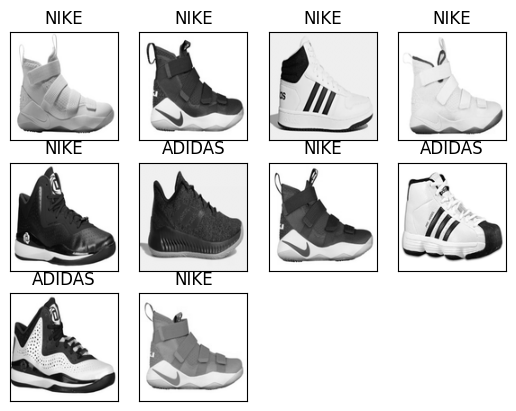

In [12]:
test_data = process_test_data()
fig = plt.figure()

for num, data_tuple in enumerate(test_data[:10]):
    img_num = data_tuple[1]
    img_data = data_tuple[0]

    y = fig.add_subplot(3,4,num+1)
    orig = img_data

    # Correctly reshape, normalize, and cast to float32 for prediction
    data_for_prediction = img_data.reshape(IMG_SIZE, IMG_SIZE, 1).astype('float32') / 255.0
    # Add a batch dimension since model.predict expects batched input
    data_for_prediction = np.expand_dims(data_for_prediction, axis=0)

    model_out = model.predict(data_for_prediction)[0]
    print(model_out)
    if np.argmax(model_out) == 1:
        str_label = 'ADIDAS'
    else:
        str_label = 'NIKE'

    y.imshow(orig, cmap = 'gray')
    plt.title(str_label)
    y.axes.get_xaxis().set_visible(False)
    y.axes.get_yaxis().set_visible(False)
plt.show()